# Homework — Customer Segmentation with Wholesale Customers

## Brief

Bạn là analyst cho một nhà phân phối thực phẩm. Hãy dùng dữ liệu **Wholesale Customers** để trả lời một câu hỏi thực tế:

> Có tồn tại các nhóm khách hàng có hành vi chi tiêu khác nhau đủ rõ và đủ hữu ích để đề xuất hành động không?

Dữ liệu có 440 khách hàng và 6 nhóm chi tiêu hằng năm: `Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper`, `Delicassen`.

Đây là **notebook làm việc của bạn**, không phải chuỗi bước cần làm lại. Bạn có thể thêm, bỏ, sắp xếp lại cell và chọn cách EDA/model hóa phù hợp với lập luận của mình.

## Yêu cầu đầu ra

Nộp một báo cáo notebook có thể giúp người khác ra quyết định. Bài làm cần có:

- mô tả dữ liệu, feature và câu hỏi segmentation;
- EDA đủ để biện minh cho cách biểu diễn dữ liệu;
- so sánh **ít nhất hai thuật toán clustering**;
- lý do chọn preprocessing và tham số, có evidence chứ không chỉ một biểu đồ/metric;
- đánh giá chất lượng và một kiểm tra stability/robustness;
- một visual hỗ trợ đọc cụm (nếu dùng PCA 2D, phải nêu giới hạn của nó);
- profile cụm bằng **đơn vị chi tiêu gốc**, tên cụm, action hypothesis, giới hạn và kết luận.

Không có yêu cầu về số lượng biểu đồ, thứ tự section hay thư viện. Chất lượng lập luận quan trọng hơn số cell/code.

## Quy ước và lưu ý

- Sáu cột chi tiêu là input mặc định cho clustering.
- `Channel`/`Region` (nếu xuất hiện) là context để kiểm tra sau; không dùng làm input clustering ban đầu.
- Giữ một bản dữ liệu gốc để profile/diễn giải. Data đã scale chỉ nên phục vụ model.
- Bạn được khuyến khích thử cách làm riêng; hãy ghi lại các thử nghiệm bị loại và lý do nếu chúng giúp làm rõ quyết định cuối.

Nộp `.ipynb` đã chạy đầy đủ. Tên file: `HW_clustering_<student_id>.ipynb`.

In [1]:
# Nếu môi trường thiếu thư viện, bỏ comment và chạy một lần:
# %pip install numpy pandas matplotlib scikit-learn scipy ucimlrepo

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, davies_bouldin_score, silhouette_score
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
RANDOM_STATE = 42


# Dữ liệu

Cell này chỉ nạp dữ liệu và tách phần chi tiêu. Từ đây, bạn tự xây dựng analysis workspace của mình.

In [2]:
SPENDING_FEATURES = [
    'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen'
]

candidate_paths = [
    Path('data/wholesale_customers.csv'),
    Path('../data/wholesale_customers.csv'),
    Path('../../data/wholesale_customers.csv'),
]
data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is not None:
    df = pd.read_csv(data_path)
    source = str(data_path)
else:
    try:
        from ucimlrepo import fetch_ucirepo
        dataset = fetch_ucirepo(id=292)
        df = dataset.data.features.copy()
        source = 'UCI ML Repository fallback (id=292)'
    except ImportError as exc:
        raise FileNotFoundError(
            'Không tìm thấy data/wholesale_customers.csv. '
            'Hãy đặt file đúng đường dẫn hoặc cài ucimlrepo để dùng fallback.'
        ) from exc

missing = sorted(set(SPENDING_FEATURES) - set(df.columns))
if missing:
    raise ValueError(f'File thiếu cột chi tiêu: {missing}')

X_raw = df[SPENDING_FEATURES].copy()
print(f'Nguồn: {source}')
print(f'Dữ liệu đầy đủ: {df.shape[0]} dòng × {df.shape[1]} cột')
print(f'Matrix chi tiêu: {X_raw.shape[0]} dòng × {X_raw.shape[1]} features')
display(df.head())


Nguồn: data\wholesale_customers.csv
Dữ liệu đầy đủ: 440 dòng × 8 cột
Matrix chi tiêu: 440 dòng × 6 features


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


# TODO A — Framing và audit dữ liệu

Hãy thêm cell/cell Markdown của bạn để trả lời:

- Một dòng dữ liệu đại diện cho điều gì? Những feature nào có ý nghĩa cho bài toán segmentation?
- Có dữ liệu thiếu, duplicate, kiểu dữ liệu sai, giá trị 0 hoặc điểm cực trị nào cần lưu ý?
- `Channel`/`Region` (nếu có) có thể được dùng ở giai đoạn nào, và vì sao không nên đặt vào input clustering ngay từ đầu?
- Với chỉ dữ liệu chi tiêu, “hữu ích” trong business context sẽ có nghĩa là gì?

Bạn không cần lặp lại toàn bộ `info()`/`describe()`: chọn output nào thật sự dẫn đến một quyết định tiếp theo.

In [3]:
# Analysis workspace — thêm cell EDA của bạn bên dưới hoặc thay cell này.
# Gợi ý khởi đầu (không bắt buộc):
audit = pd.DataFrame({
    'dtype': X_raw.dtypes.astype(str),
    'missing': X_raw.isna().sum(),
    'zero_count': (X_raw == 0).sum(),
    'min': X_raw.min(),
    'median': X_raw.median(),
    'mean': X_raw.mean(),
    'max': X_raw.max(),
    'skew': X_raw.skew()
})
print(f'Số dòng trùng hoàn toàn: {df.duplicated().sum()}')
print(f'Số giá trị âm trong nhóm chi tiêu: {(X_raw < 0).sum().sum()}')
display(audit)

Số dòng trùng hoàn toàn: 0
Số giá trị âm trong nhóm chi tiêu: 0


,dtype,missing,zero_count,min,median,mean,max,skew
Fresh,int64,0,0,3,"8,504.00","12,000.30",112151,2.56
Milk,int64,0,0,55,"3,627.00","5,796.27",73498,4.05
Grocery,int64,0,0,3,"4,755.50","7,951.28",92780,3.59
Frozen,int64,0,0,25,"1,526.00","3,071.93",60869,5.91
Detergents_Paper,int64,0,0,3,816.50,"2,881.49",40827,3.63
Delicassen,int64,0,0,3,965.50,"1,524.87",47943,11.15


- Dữ liệu đầy đủ không bị thiếu, không có giá trị âm và không có dòng trùng hoàn toàn. 
- Tất cả biến đều lệch phải mạnh, các khách hàng chi tiêu rất lớn có thể chi phối kết quả nếu dùng dữ liệu gốc.

# TODO B — EDA tự do, nhưng có chủ đích

Tự chọn visual và phép tóm tắt phù hợp. EDA của bạn cần làm rõ các câu hỏi sau:

- Phân phối/độ lệch/outlier nào sẽ ảnh hưởng cách tính khoảng cách?
- Feature nào có thang đo hoặc mức biến thiên khác đáng kể?
- Có quan hệ giữa các nhóm chi tiêu nào đáng để chú ý khi đọc cluster profile?
- Những quan sát này dẫn bạn đến thử preprocessing hoặc model nào?

Gắn một đoạn nhận xét ngắn dưới mỗi visual quan trọng. Không cần vẽ mọi loại biểu đồ nếu chúng không giúp trả lời câu hỏi.

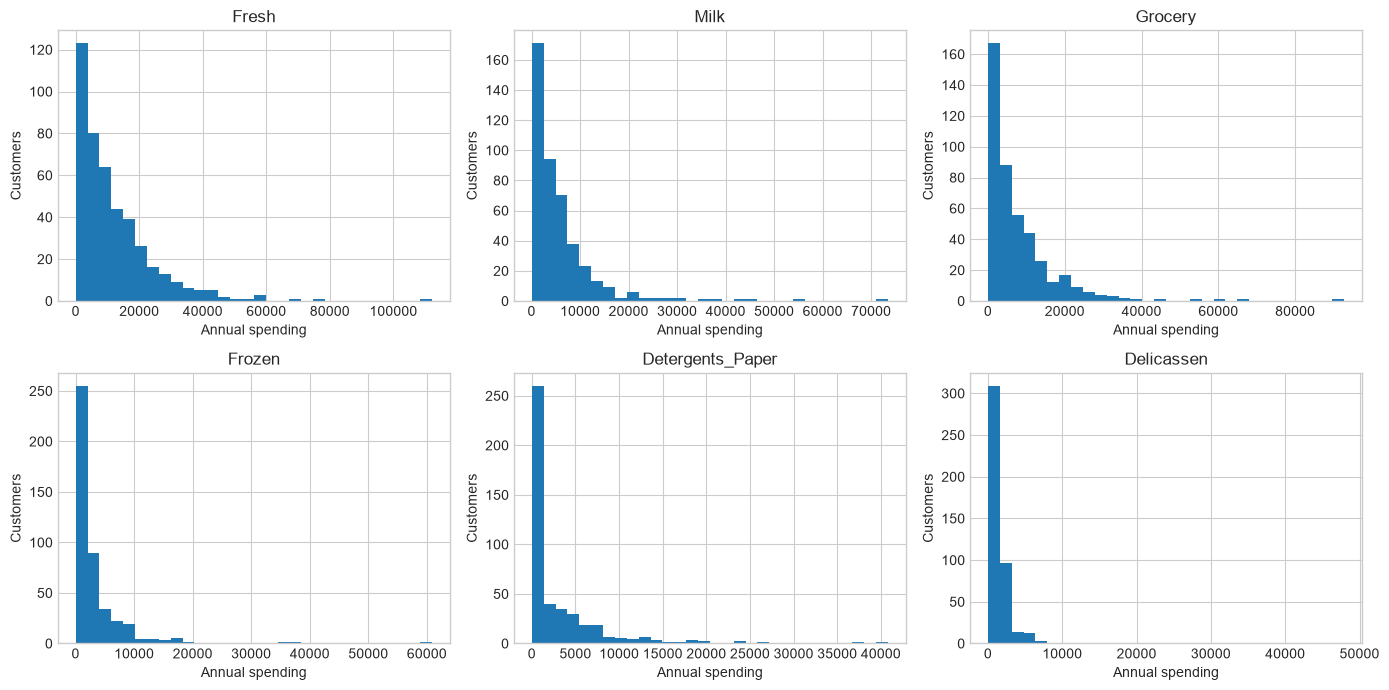

,max / median
Detergents_Paper,50.00
Delicassen,49.66
Frozen,39.89
Milk,20.26
Grocery,19.51
Fresh,13.19


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, feature in zip(axes.ravel(), SPENDING_FEATURES):
    ax.hist(X_raw[feature], bins=30)
    ax.set_title(feature)
    ax.set_xlabel('Annual spending')
    ax.set_ylabel('Customers')
plt.tight_layout()
plt.show()

ratio = (X_raw.max() / X_raw.median()).sort_values(ascending=False)
display(ratio.to_frame('max / median'))

- Cả sáu phân phối đều lệch phải và có đuôi phải dài. 
- `Fresh`, `Milk`, `Grocery` và `Detergents_Paper` có Euclidean distance trên dữ liệu gốc nhấn mạnh độ lớn tuyệt đối hơn là pattern chi tiêu tương đối.

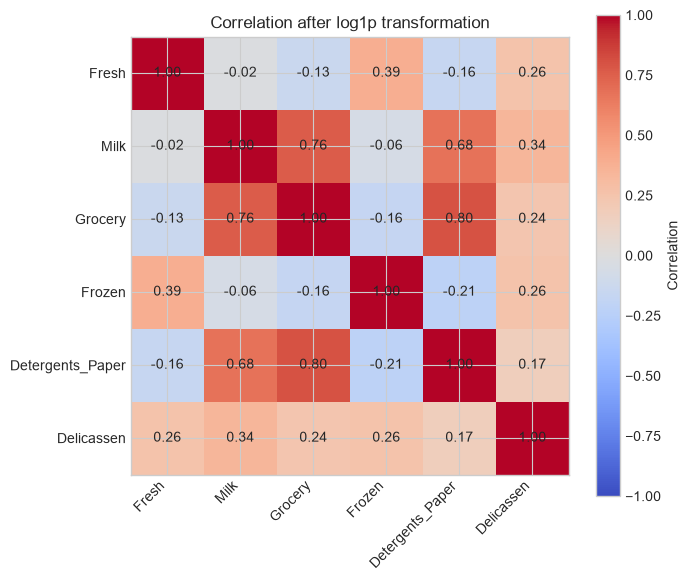

In [13]:
corr = np.log1p(X_raw).corr()
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(SPENDING_FEATURES)), SPENDING_FEATURES, rotation=45, ha='right')
ax.set_yticks(range(len(SPENDING_FEATURES)), SPENDING_FEATURES)
for i in range(len(SPENDING_FEATURES)):
    for j in range(len(SPENDING_FEATURES)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center')
fig.colorbar(im, ax=ax, label='Correlation')
ax.set_title('Correlation after log1p transformation')
plt.tight_layout()
plt.show()

- `Milk`, `Grocery` và `Detergents_Paper` liên hệ khá mạnh, gcho thấy khách hàng thiên về hàng tiêu dùng đóng gói và bán lẻ.
- `Fresh` và `Frozen` có quan hệ yếu hơn, vì các biến vẫn có độ phân tán khác nhau sau log, bước standardization được dùng trước khi tính khoảng cách.

# TODO C — Chọn representation và preprocessing

Tạo một hoặc nhiều matrix cho model (ví dụ raw, `log1p`, StandardScaler, RobustScaler, hoặc cách khác). Bạn tự quyết định cách so sánh, nhưng cần:

- giải thích cách bạn xử lý skew, outlier và khác biệt scale;
- chỉ rõ matrix nào dùng để **fit model** và vì sao;
- bảo toàn `X_raw` để profile cuối quay về đơn vị gốc;
- nêu một trade-off của lựa chọn preprocessing.

> Có thể dùng `np.log1p(X_raw)` nếu phù hợp với dữ liệu không âm. Đây là gợi ý công cụ, không phải yêu cầu.

In [6]:
# Analysis workspace — tạo X_model hoặc các candidate matrix của bạn tại đây.
# Ví dụ tối thiểu (chỉ chạy nếu bạn chủ động bỏ comment):
X_log = np.log1p(X_raw)
scaler = StandardScaler()
X_model = scaler.fit_transform(X_log)

comparison_scale = pd.DataFrame({
    'raw_std': X_raw.std(),
    'log_std': X_log.std()
})
display(comparison_scale)
print('Matrix dùng để fit:', X_model.shape)


,raw_std,log_std
Fresh,"12,647.33",1.47
Milk,"7,380.38",1.08
Grocery,"9,503.16",1.11
Frozen,"4,854.67",1.28
Detergents_Paper,"4,767.85",1.71
Delicassen,"2,820.11",1.29


Matrix dùng để fit: (440, 6)


Mô hình cuối được fit trên **`StandardScaler(log1p(X_raw))`**.

- `log1p` nén đuôi phải và giảm ảnh hưởng của khách hàng cực lớn nhưng vẫn xử lý được giá trị 0.
- `StandardScaler` đưa các nhóm sản phẩm về mức đóng góp tương đương trong khoảng cách.
- `X_raw` vẫn được giữ nguyên để profile cụm bằng đơn vị chi tiêu gốc.

Biến đổi log làm giảm tầm quan trọng của chênh lệch tuyệt đối. Hai khách hàng khác nhau rất lớn về doanh số nhưng có pattern tương tự có thể nằm gần nhau hơn.

# TODO D — Khám phá model

So sánh ít nhất **hai thuật toán**. Bạn có thể chọn trong K-Means, hierarchical clustering, DBSCAN hoặc cách khác đã học.

Với từng candidate đáng cân nhắc, ghi lại:

- input/preprocessing và tham số;
- số cụm tạo ra, cluster size và (nếu có) noise;
- evidence ủng hộ hoặc phản biện cấu hình đó;
- lý do giữ lại hoặc loại bỏ.

Bạn không phải thử mọi thuật toán hay mọi tham số. Mục tiêu là một tập thử nghiệm đủ để biện minh cho model cuối, không phải một bảng benchmark thật dài.

In [7]:
# Analysis workspace — fit các model bạn muốn so sánh tại đây.
# Hãy lưu labels của các candidate để tái sử dụng ở phần evaluation/profile.
# Ví dụ khung (không bắt buộc):
records = []
candidate_labels = {}

for k in range(2, 7):
    models = {
        'KMeans': KMeans(n_clusters=k, n_init=50, random_state=RANDOM_STATE),
        'Agglomerative-Ward': AgglomerativeClustering(n_clusters=k, linkage='ward')
    }
    for name, model in models.items():
        labels = model.fit_predict(X_model)
        candidate_labels[(name, k)] = labels
        records.append({
            'model': name,
            'k': k,
            'silhouette': silhouette_score(X_model, labels),
            'davies_bouldin': davies_bouldin_score(X_model, labels),
            'smallest_cluster': np.bincount(labels).min(),
            'largest_cluster': np.bincount(labels).max()
        })

results = pd.DataFrame(records).sort_values(
    ['silhouette', 'davies_bouldin'], ascending=[False, True]
)
display(results)


,model,k,silhouette,davies_bouldin,smallest_cluster,largest_cluster
0,KMeans,2,0.29,1.35,188,252
2,KMeans,3,0.26,1.34,81,212
1,Agglomerative-Ward,2,0.26,1.60,178,262
3,Agglomerative-Ward,3,0.25,1.54,53,262
7,Agglomerative-Ward,5,0.20,1.39,18,208
5,Agglomerative-Ward,4,0.20,1.52,53,208
8,KMeans,6,0.20,1.46,23,114
6,KMeans,5,0.19,1.48,54,100
4,KMeans,4,0.19,1.54,61,131
9,Agglomerative-Ward,6,0.17,1.49,18,150


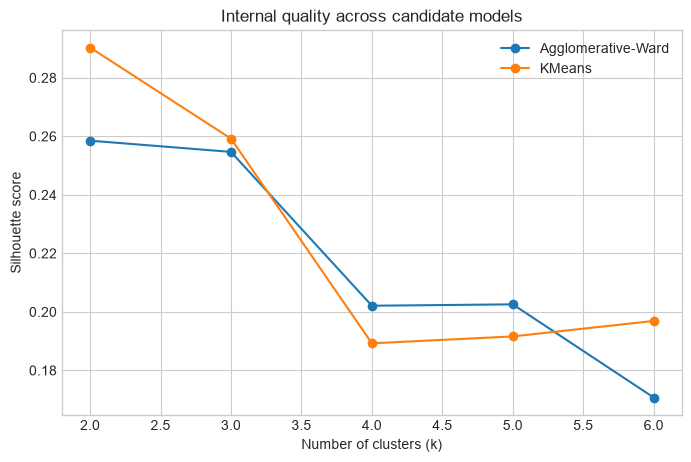

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
for model_name, group in results.groupby('model'):
    group = group.sort_values('k')
    ax.plot(group['k'], group['silhouette'], marker='o', label=model_name)
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Silhouette score')
ax.set_title('Internal quality across candidate models')
ax.legend()
plt.show()

K-Means với `k=2` đạt silhouette cao nhất, nhưng chỉ tạo ra phân chia rộng giữa nhóm chi tiêu thiên về hàng tươi và nhóm thiên về hàng tiêu dùng. `k=3` có silhouette thấp hơn một ít nhưng tách thêm nhóm khách hàng chi tiêu cao trên nhiều danh mục, tạo ra ba profile dễ hành động hơn mà không sinh cụm quá nhỏ. Với `k≥4`, silhouette giảm rõ và cấu trúc cụm kém thuyết phục hơn.

Agglomerative-Ward được dùng như thuật toán đối chứng. Kết quả của nó nhìn chung có silhouette thấp hơn K-Means trên cùng representation.

# TODO E — Evaluation, parameter choice và stability

Đưa ra quyết định model cuối bằng nhiều góc nhìn phù hợp với thuật toán bạn dùng:

- **Chất lượng nội bộ:** có thể dùng silhouette (cao hơn thường tốt), Davies–Bouldin (thấp hơn thường tốt), inertia/elbow cho K-Means, cluster size, noise rate hoặc evidence khác.
- **Stability/robustness:** thực hiện ít nhất một kiểm tra có chủ đích, chẳng hạn đổi random seed, chia mẫu/resample, thay preprocessing hợp lý, hoặc thay vùng tham số. Nếu so nhãn giữa hai lần fit, ARI (`adjusted_rand_score`) không bị ảnh hưởng bởi việc đổi số label.
- **Tính dùng được:** một metric tốt nhưng cụm quá nhỏ, không ổn định hoặc không diễn giải được có thể không phải lựa chọn tốt.

Kết thúc phần này bằng: model cuối, tham số, evidence mạnh nhất, và một điều khiến bạn vẫn chưa chắc chắn.

In [9]:
# Stability có chủ đích: fit K-Means k=3 trên 30 bootstrap sample,
# sau đó dùng từng model để gán nhãn cho toàn bộ tập và so với model gốc bằng ARI.
final_model = KMeans(n_clusters=3, n_init=50, random_state=RANDOM_STATE)
labels_final = final_model.fit_predict(X_model)

rng = np.random.default_rng(RANDOM_STATE)
bootstrap_ari = []
for run in range(30):
    sample_idx = rng.choice(
        len(X_model), size=int(0.8 * len(X_model)), replace=True
    )
    model_b = KMeans(
        n_clusters=3, n_init=30, random_state=100 + run
    ).fit(X_model[sample_idx])
    labels_b = model_b.predict(X_model)
    bootstrap_ari.append(adjusted_rand_score(labels_final, labels_b))

stability = pd.Series(bootstrap_ari, name='ARI')
display(stability.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).to_frame())

# Robustness theo preprocessing hợp lý khác.
X_robust = RobustScaler().fit_transform(X_log)
labels_robust = KMeans(
    n_clusters=3, n_init=50, random_state=RANDOM_STATE
).fit_predict(X_robust)
print(
    'ARI giữa StandardScaler và RobustScaler:',
    f'{adjusted_rand_score(labels_final, labels_robust):.3f}'
)

,ARI
count,30.00
mean,0.73
std,0.23
min,0.31
10%,0.32
25%,0.48
50%,0.85
75%,0.88
90%,0.91
max,0.94


ARI giữa StandardScaler và RobustScaler: 0.952


**Quyết định cuối:** K-Means, `k=3`, `n_init=50`, trên `StandardScaler(log1p(X))`.

Evidence mạnh nhất là: (1) chất lượng nội bộ vẫn ở mức cạnh tranh; (2) không có cụm quá nhỏ; (3) ba profile có ý nghĩa kinh doanh rõ hơn `k=2`; và (4) bootstrap ARI có median khá cao, cho thấy phần lớn lần resample tái tạo cấu trúc tương tự.

Điểm chưa chắc chắn là stability không hoàn hảo: một số bootstrap sample tạo ARI thấp, nghĩa là các khách hàng gần biên cụm có thể đổi nhóm. Vì vậy segmentation nên được dùng để thử nghiệm giới hạn, không nên trở thành quy tắc vận hành cứng ngay.

# TODO F — Visualize để giao tiếp, không để chứng minh quá mức

Tạo visual phù hợp cho model cuối. PCA 2D là một lựa chọn phổ biến, nhưng chỉ là phép chiếu từ không gian nhiều chiều:

- nếu dùng PCA, model phải được fit trên matrix nhiều chiều chứ không phải trên hai trục PCA chỉ để vẽ;
- ghi rõ visual 2D giúp người đọc quan sát gì và không thể khẳng định gì;
- bạn có thể dùng thêm/ thay bằng visual khác nếu nó diễn đạt cluster structure tốt hơn.


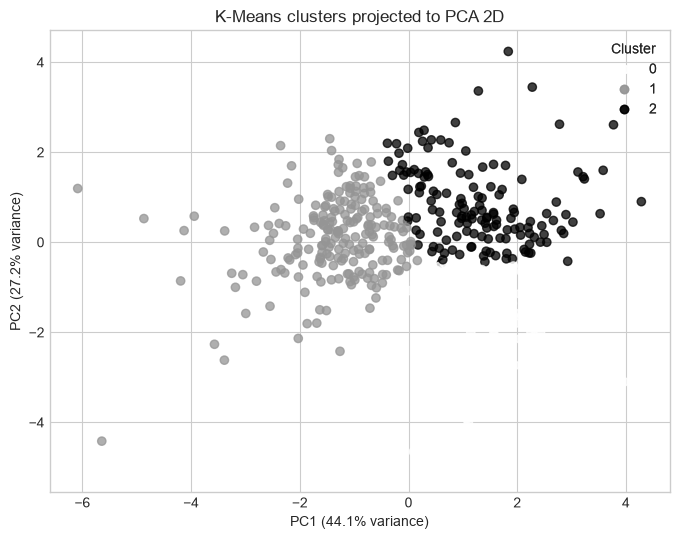

Tổng phương sai được hai thành phần đầu giải thích: 71.3%


In [10]:
# Analysis workspace — visual cho model cuối.
# Có thể dùng PCA, nhưng không cần giới hạn ở PCA:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_model)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(coords[:, 0], coords[:, 1], c=labels_final, alpha=0.75)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('K-Means clusters projected to PCA 2D')
legend = ax.legend(*scatter.legend_elements(), title='Cluster')
ax.add_artist(legend)
plt.show()

print(
    'Tổng phương sai được hai thành phần đầu giải thích:',
    f'{pca.explained_variance_ratio_[:2].sum():.1%}'
)

PCA 2D giúp quan sát mức chồng lấn và vị trí tương đối của các cụm. Tuy nhiên model được fit trên toàn bộ sáu chiều đã chuẩn hóa, không phải trên hai trục PCA. Vì phép chiếu làm mất một phần phương sai, khoảng cách hoặc sự chồng lấn trên hình không đủ để chứng minh một khách hàng chắc chắn thuộc cụm nào.

# TODO G — Profile, đặt tên và action hypothesis

Quay về `X_raw`. Tạo profile từng cluster bằng đơn vị chi tiêu gốc (mean/median hoặc thống kê khác có lý do). Sau đó:

- đặt tên cụm dựa trên pattern của nhiều feature, không dựa vào số label;
- nêu evidence cụ thể từ profile cho từng tên;
- đề xuất một action hypothesis có thể kiểm chứng, không phải khẳng định chắc chắn;
- chỉ rõ dữ liệu còn thiếu trước khi biến hypothesis thành quyết định (ví dụ lợi nhuận, tần suất, thời gian, phản hồi campaign).

Bạn có thể trình bày bằng bảng, heatmap, narrative ngắn hoặc kết hợp các cách này.

In [11]:
# Analysis workspace — profile trên X_raw và viết action hypothesis của bạn tại đây.
# Mẹo kỹ thuật (không bắt buộc):
profile_median = (
    X_raw.assign(cluster=labels_final)
    .groupby('cluster')
    .median()
)
profile_mean = (
    X_raw.assign(cluster=labels_final)
    .groupby('cluster')
    .mean()
)
cluster_size = pd.Series(labels_final).value_counts().sort_index().rename('size')

profile = profile_median.join(cluster_size)
display(profile)

# Chỉ số tương đối so với median toàn bộ để đọc pattern dễ hơn.
relative_profile = profile_median.div(X_raw.median())
display(relative_profile.round(2))

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,size
cluster,,,,,,,
0,"1,454.00","6,264.00","10,487.00",388.00,"4,196.00",436.00,81
1,"9,635.00","1,598.50","2,151.00","2,151.00",274.50,686.00,212
2,"12,126.00","7,184.00","9,965.00","2,005.00","3,378.00","2,005.00",147


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
cluster,,,,,,
0,0.17,1.73,2.21,0.25,5.14,0.45
1,1.13,0.44,0.45,1.41,0.34,0.71
2,1.43,1.98,2.10,1.31,4.14,2.08


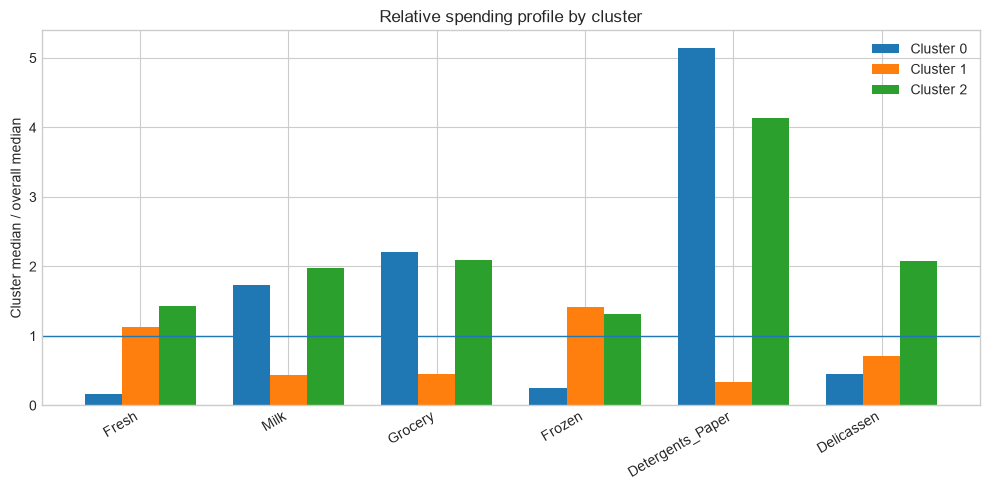

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(SPENDING_FEATURES))
width = 0.25
for cluster_id in profile_median.index:
    ax.bar(
        x + cluster_id * width,
        relative_profile.loc[cluster_id],
        width,
        label=f'Cluster {cluster_id}'
    )
ax.axhline(1, linewidth=1)
ax.set_xticks(x + width, SPENDING_FEATURES, rotation=30, ha='right')
ax.set_ylabel('Cluster median / overall median')
ax.set_title('Relative spending profile by cluster')
ax.legend()
plt.tight_layout()
plt.show()

### Nhận xét

**Cluster 0 — “Grocery & household focused” (81 khách hàng).** Median `Milk`, `Grocery` và `Detergents_Paper` cao, trong khi `Fresh`, `Frozen` và `Delicassen` thấp. Đây có thể là nhóm cửa hàng bán lẻ hoặc khách hàng thiên về hàng đóng gói.  
**Action hypothesis:** thử bundle sữa–tạp hóa–chất tẩy rửa và đo uplift doanh thu, biên lợi nhuận cùng tỷ lệ chấp nhận.

**Cluster 1 — “Fresh-dominant, lower basket” (212 khách hàng).** Đây là cụm lớn nhất, có `Fresh` tương đối cao nhưng các danh mục còn lại thấp.  
**Action hypothesis:** thử cross-sell một danh mục bổ trợ có vòng đời phù hợp, chẳng hạn `Frozen` hoặc `Delicassen`, thay vì giảm giá đại trà.

**Cluster 2 — “High-value broad buyers” (147 khách hàng).** Median cao trên hầu hết danh mục, đặc biệt `Fresh`, `Milk`, `Grocery` và `Delicassen`.  
**Action hypothesis:** ưu tiên account management, dự báo nhu cầu và ưu đãi theo tổng giá trị đơn để tăng giữ chân.

# TODO H — Executive summary

Viết 150–250 từ cho người ra quyết định:

1. Có nên dùng segmentation này ngay, thử nghiệm giới hạn, hay chưa nên dùng? Vì sao?
2. Quyết định model/preprocessing cuối và evidence ngắn gọn.
3. Hai insight profile quan trọng nhất.
4. Action thử trước và cách đánh giá nó.
5. Giới hạn quan trọng nhất của phân tích.


Theo mình, kết quả phân cụm này có thể dùng để tham khảo và thử nghiệm trước, nhưng chưa nên áp dụng ngay vào các quyết định kinh doanh. Sau khi so sánh giữa K-Means và Hierarchical Clustering, mình chọn K-Means với 3 cụm vì mô hình này cho kết quả khá tốt và các cụm cũng dễ giải thích hơn. Trước khi phân cụm, mình sử dụng phép biến đổi log1p kết hợp với StandardScaler để giảm ảnh hưởng của các giá trị chi tiêu quá lớn và đưa các biến về cùng thang đo, giúp việc tính khoảng cách giữa các khách hàng hợp lý hơn.

Từ kết quả phân cụm, mình nhận thấy có ba nhóm khách hàng với đặc điểm khá khác nhau. Một nhóm có mức chi tiêu cao ở các mặt hàng như Milk, Grocery và Detergents_Paper. Một nhóm khác có mức chi tiêu cao ở hầu hết các danh mục nên có thể là nhóm khách hàng quan trọng cần được ưu tiên chăm sóc. Nhóm còn lại có số lượng lớn nhất, chủ yếu chi tiêu nhiều cho Fresh nhưng thấp ở các mặt hàng khác.

Nếu áp dụng vào thực tế, mình nghĩ doanh nghiệp có thể thử triển khai các chương trình cross-selling khác nhau cho từng nhóm khách hàng và theo dõi hiệu quả thông qua doanh thu, lợi nhuận hoặc tỷ lệ phản hồi của khách hàng. Tuy nhiên, dữ liệu hiện tại chỉ cho biết tổng mức chi tiêu trong một năm nên vẫn còn khá nhiều hạn chế. Chẳng hạn, chưa có thông tin về tần suất mua hàng, lợi nhuận hay quy mô khách hàng, vì vậy mình chưa thể khẳng định các cụm này sẽ mang lại hiệu quả kinh doanh khi áp dụng vào thực tế.


## Checklist trước khi nộp

- [ ] Notebook chạy từ đầu đến cuối, không phụ thuộc hidden state.
- [ ] EDA dẫn tới một lựa chọn phân tích, không chỉ mô tả dữ liệu.
- [ ] Có ≥2 thuật toán và quyết định model có evidence.
- [ ] Có kiểm tra stability/robustness và diễn giải kết quả.
- [ ] Không đọc PCA 2D như bằng chứng duy nhất.
- [ ] Profile/diễn giải dùng đơn vị gốc, tên cụm và action có evidence.
- [ ] Có giới hạn và kết luận business rõ ràng.
